# 00 LSTM Models With True Sequences Using 80/20 Train/Test Split
This and the next notebook use nearly the exact same models as the "Improved Models" notebooks that we tested previously. However, we have corrected our normalization process in these notebooks. Instead of normalizing all price features to the Open of the current day (and the volume features to the Previous Day Volume), we scaled everything to the maximum for all the dates for each ticker. A more in-depth explanation is provided below when we create this sequence data.

## Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Getting S&P500 Table Data

### Old method (risky since S&P500 Wikipedia might change randomly)

As of March 11, 2025, the last time a stock was added or removed from the S&P500 Wikipedia list was in December 2024. Therefore, for the extent of this project thus far, this shouldn't have affected us at all. However, we should keep a consistent csv of the stocks so we can have consistent GICS sectors (in case they change for some reason).

In [27]:
# Getting the S&P500 tables
sp500_tables = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')

In [26]:
# Getting the S&P500 list into a csv (only need to do once)
# df_sp500 = sp500_tables[0]
# df_sp500.to_csv('SP500_Tickers_March_2025.csv')

### Get S&P500 current list of stocks and their sectors using downloaded csv file

In [2]:
sp500_tables = pd.read_csv('SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [3]:
# Loading in stock data
data = pd.read_csv("SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [4]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [5]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Outcome variables - Close price minus the Open price and variations of that

In [6]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [7]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [8]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [9]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [11]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features
**This is where we** ***correctly*** **scale our features for proper time-series LSTM modeling.**

As we will explain in more detail in throughout this section, we normalize to the maximum of each ticker (instead of to each current day's Open like we did in previous notebooks) in order to preserve long-term price changes. In essence, this means that for most of the days for every ticker, the values will be between 0 and some maximum, with only a few of the days ever reaching that maximum. We decide to have our normalized maximum be equal to 2, so any values that are scaled using this process will range from 2 down to 0 (if there are any that go that low). We choose 2 because we want the mean of these scaled features to be ~1, which matches nicely with the mean of the other features not scaled this way (e.g., NATR or RSI). This will hopefully help the training, as we want our learning rate to affect all the features with roughly the same magnitude.

We also double-check that the percent differences between features (e.g., percent difference between the Previous Day Low and the Previous Day Close) remain the same for each day across all the tickers after scaling, as we want to keep these proportional differences in the data. One example could be the following: if the previous OHLC prices for a day were 100, 120, 60, and 80, they may be scaled down to 0.5, 0.6, 0.3, and 0.4, with their relative percent differences remaining intact. Notice as well that none of these values reach 2, which means the global maximum price for this ticker within this time period is not on this particular day.

In [12]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [13]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [14]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [15]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [16]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [17]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [18]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [19]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [23]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

# LSTM Model Testing with 80/20 Train/Test Split

## Splitting the data into train and test sets

In [219]:
# Getting the number of unique dates and tickers in data
unique_dates = data_small.index.nunique()
unique_tickers = data_small['Ticker'].nunique()

# Splitting the data into train and test sets
train_size = int(0.8 * unique_dates) * unique_tickers  # Need to make sure full series are split (which requires integers)
# ^Another way to think about it: regardless of the unique_dates value, we need to go up by the number of tickers (e.g., 400) at an
# ^integer amount each time
train_data = data_small[:train_size]
test_data = data_small[train_size:]

In [220]:
train_data.head()

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,GICS Sector,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,-0.203723,1.339836,1.372728,1.349311,1.353202,0.526987,2.644600,Health Care,0.147131,1
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,-0.244626,1.687894,1.406148,1.752718,1.703631,0.706708,5.388523,Other,4.311770,2
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,0.156550,1.375406,1.321845,1.412370,1.365306,0.637339,2.836645,Other,0.658296,2
2021-03-17,2021-03-17,AAPL,0.934135,0.946559,0.958006,0.939180,0.945581,0.723158,-1.210472,False,...,-0.115070,0.919101,0.977241,0.924433,0.932894,0.501099,2.984106,Information Technology,0.572349,2
2021-03-17,2021-03-17,ABBV,0.862444,0.913895,0.923287,0.913479,0.921292,0.218683,-6.387578,True,...,2.073404,0.895596,0.890557,0.902036,0.905034,0.633379,1.750271,Health Care,1.233615,2


In [221]:
test_data.head()

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,GICS Sector,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,,,,,,,,,,
2024-04-01,2024-04-01,A,1.657652,1.670360,1.671945,1.645680,1.647378,0.443387,0.623652,False,...,-0.483575,1.662177,1.564521,1.655880,1.638654,0.549293,1.901196,Health Care,-0.424131,1
2024-04-01,2024-04-01,AAL,1.182062,1.171330,1.188195,1.159831,1.176696,0.438950,0.456024,False,...,-0.111863,1.112961,1.126317,1.141189,1.130769,0.625053,2.140531,Other,-0.064852,1
2024-04-01,2024-04-01,AAP,0.750297,0.743087,0.749776,0.738657,0.739178,0.133728,1.504305,False,...,-0.563579,0.719433,0.614304,0.728257,0.693017,0.740470,3.066500,Other,-1.088344,0
2024-04-01,2024-04-01,AAPL,1.311594,1.315884,1.319562,1.306384,1.313816,0.412155,-0.169099,False,...,-0.329976,1.324477,1.388300,1.320863,1.333984,0.424560,1.786966,Information Technology,-0.677612,0
2024-04-01,2024-04-01,ABBV,1.708878,1.700610,1.712824,1.694033,1.710945,0.212735,-0.120810,False,...,-0.494911,1.684523,1.640609,1.687376,1.678696,0.624931,1.317172,Health Care,-0.615796,0


## Creating dummy variables for GICS Sector
Normally, we would create dummy variables after we separate the data into features and outcome variables. However, it would be much more cumbersome to do in our case because we need a 3-dimensional array for our LSTM sequence inputs. Therefore, we opt to create the dummy variables now to avoid that problem later on. One note is that because our test data is simply a time-series of the same tickers and features, we don't need to worry about "out of sample" tickers, as all tickers in the training data will be in the test data as well.

In [222]:
train_data.shape

(362900, 25)

In [223]:
# Getting train and test dummy variables for GICS Sector
sector_train_d = pd.get_dummies(
    train_data['GICS Sector'],
    drop_first = False
)
sector_test_d = pd.get_dummies(
    test_data['GICS Sector'],
    drop_first = False
)
print("Number of train_data dummy variables:", train_data['GICS Sector'].nunique())
print("Shape of train_data dummy variable for GICS Sector:",
      sector_train_d.shape, '\n')
print("Number of test_data dummy variables:", test_data['GICS Sector'].nunique())
print("Shape of test_data dummy variable for GICS Sector:",
      sector_test_d.shape, '\n')

# Adding the dummy variables to train_data and test_data
train_data = pd.concat(
    [train_data, sector_train_d],
    axis=1
)
test_data = pd.concat(
    [test_data, sector_test_d],
    axis=1
)


Number of train_data dummy variables: 12
Shape of train_data dummy variable for GICS Sector: (362900, 12) 

Number of test_data dummy variables: 12
Shape of test_data dummy variable for GICS Sector: (90725, 12) 



In [224]:
# Checking to make sure dummies were created correctly
train_data.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [225]:
# Removing GICS Sector since we've converted it to one-hot encoding
train_data = train_data.drop("GICS Sector", axis = 1)
test_data = test_data.drop("GICS Sector", axis = 1)

print("Shape of train_data after removing original GICS Sector feature:",
      train_data.shape)
print("Shape of test_data after removing original GICS Sector feature:",
      test_data.shape)

Shape of train_data after removing original GICS Sector feature: (362900, 36)
Shape of test_data after removing original GICS Sector feature: (90725, 36)


## Function for Creating Sequences for LSTM Model

In [226]:
train_data.columns

Index(['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV',
       'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_prev_14', 'SMA_prev_50',
       'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14',
       'Close_Open_Diff_Perc', 'Close_Open_Diff_Ternary',
       'Communication Services', 'Consumer Discretionary', 'Consumer Staples',
       'Energy', 'Financials', 'Health Care', 'Industrials',
       'Information Technology', 'Materials', 'Other', 'Real Estate',
       'Utilities'],
      dtype='object')

When creating sequences for the LSTM model, we have to keep in mind that we have (effectively) independent series for each ticker. In essence, each timestamp will be repeated ~500 times, and we need to ensure we separate each time series based on their ticker

In [227]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)
    
    return X, Y

## LSTM Classification (all stocks, sector dummy features included)

### Getting X sequence data and Y labels for LSTM model

In [185]:
# Creating sequences for LSTM model
seq_length = 14
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_train, Y_train = create_sequences_grouped(train_data, seq_length, group_col, target_col, drop_cols)
X_test, Y_test = create_sequences_grouped(test_data, seq_length, group_col, target_col, drop_cols)

In [186]:
# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming that we should have the correct number of sequences in X_train
unique_train_tickers = train_data['Ticker'].nunique()
unique_train_dates = train_data['Date_col'].nunique()
expected_num_sequences = unique_train_tickers * (unique_train_dates - seq_length + 1)

print('Number of unique tickers in data_train:', unique_train_tickers)
print('Number of unique dates in data_train:', unique_train_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_train_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of train sequences expected:', expected_num_sequences)
print('Total number of train sequences achieved:', X_train.shape[0])

Shape of X_train: (356725, 14, 32)
Shape of Y_train: (356725,)
Shape of X_test: (84550, 14, 32)
Shape of Y_test: (84550,) 

Number of unique tickers in data_train: 475
Number of unique dates in data_train: 764
Chosen sequence length: 14
Number of sequences assuming the above seq_length: 751
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of train sequences expected: 356725
Total number of train sequences achieved: 356725


In [187]:
# Double checking to make sure X_train worked:
X_train[0][0:2]

array([[ 1.3587323 ,  1.3854982 ,  1.3917177 ,  1.3599539 ,  1.3660624 ,
         0.2740996 , -0.5365773 ,  0.        ,  0.        ,  0.        ,
        -0.08982197,  1.        ,  0.3717289 , -0.20372342,  1.3398359 ,
         1.3727282 ,  1.349311  ,  1.3532023 ,  0.5269875 ,  2.6445997 ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 1.372726  ,  1.3587323 ,  1.3672842 ,  1.3494033 ,  1.3607315 ,
         0.29599902,  0.8814737 ,  0.        ,  0.39799982,  1.        ,
         0.        ,  0.        ,  0.3720505 ,  0.13205703,  1.3401691 ,
         1.3735901 ,  1.3515952 ,  1.3539194 ,  0.515678  ,  2.5552683 ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ]], dtype=float32)

In [188]:
# Comparing it with the original train_data
train_data_2 = train_data.sort_values(['Ticker', 'Date_col'])
train_data_2.head(2)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-18,2021-03-18,A,1.372726,1.358732,1.367284,1.349403,1.360732,0.295999,0.881474,False,...,False,False,False,True,False,False,False,False,False,False


Based on the values above, they do seem to match appropriately (the last 2 sequences in the first training example match)

### Building and compiling LSTM model

In [189]:
# Defining a function to create and compile tf model
def build_LSTM_model(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=128, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=128, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Default Model

In [190]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.0001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 1024

# Building and compiling the model
model_LSTM_default = build_LSTM_model(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_default.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,403 (837.51 KB)

 Trainable params: 214,403 (837.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [191]:
# Training the model using the training dataset
model_LSTM_default_fit = model_LSTM_default.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.1,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.3715 - loss: 1.0875 - val_accuracy: 0.3902 - val_loss: 1.0780
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.3866 - loss: 1.0803 - val_accuracy: 0.3942 - val_loss: 1.0761
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.3901 - loss: 1.0784 - val_accuracy: 0.3991 - val_loss: 1.0746
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.3918 - loss: 1.0768 - val_accuracy: 0.4006 - val_loss: 1.0731
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.3949 - loss: 1.0753 - val_accuracy: 0.4043 - val_loss: 1.0713
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.3995 - loss: 1.0735 - val_accuracy: 0.4094 - val_loss: 1.0695
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.4016 - loss: 1.0718 - val_accuracy: 0.4108 - val_loss: 1.0683
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.4038 - loss: 1

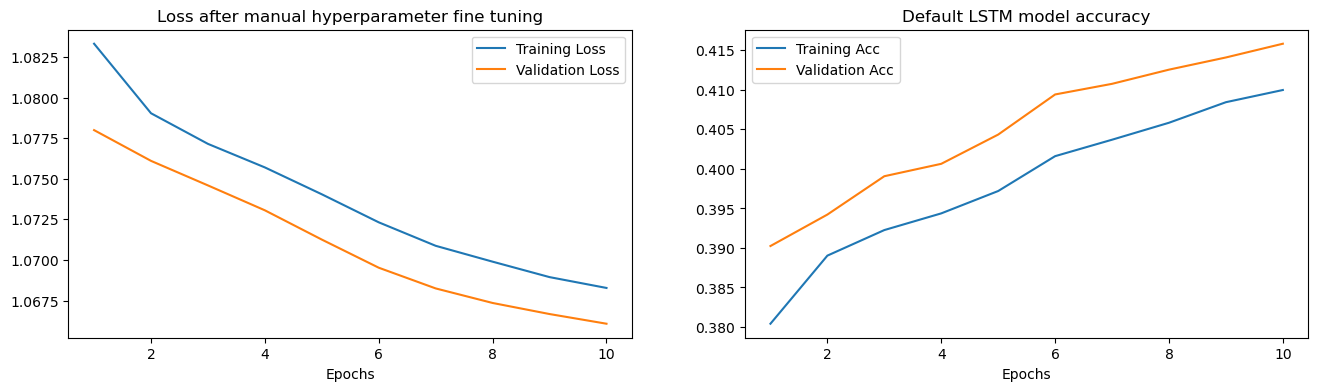

In [192]:
# Plotting the loss on the first subplot
hist_d = model_LSTM_default_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_d['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_d['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_d['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_d['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Default LSTM model accuracy')
plt.show()

### Manual hyperparameter-tuned LSTM model

In [195]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 1024

# Building and compiling the model
model_LSTM_manual = build_LSTM_model(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_manual.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,403 (837.51 KB)

 Trainable params: 214,403 (837.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [196]:
# Training the model using the training dataset
model_LSTM_manual_fit = model_LSTM_manual.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.1,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.3810 - loss: 1.0836 - val_accuracy: 0.4057 - val_loss: 1.0685
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.4074 - loss: 1.0690 - val_accuracy: 0.4226 - val_loss: 1.0625
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.4207 - loss: 1.0627 - val_accuracy: 0.4315 - val_loss: 1.0560
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.4300 - loss: 1.0574 - val_accuracy: 0.4392 - val_loss: 1.0518
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.4394 - loss: 1.0518 - val_accuracy: 0.4487 - val_loss: 1.0448
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.4515 - loss: 1.0428 - val_accuracy: 0.4597 - val_loss: 1.0340
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.4644 - loss: 1.0303 - val_accuracy: 0.4712 - val_loss: 1.0233
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.4764 - loss: 1

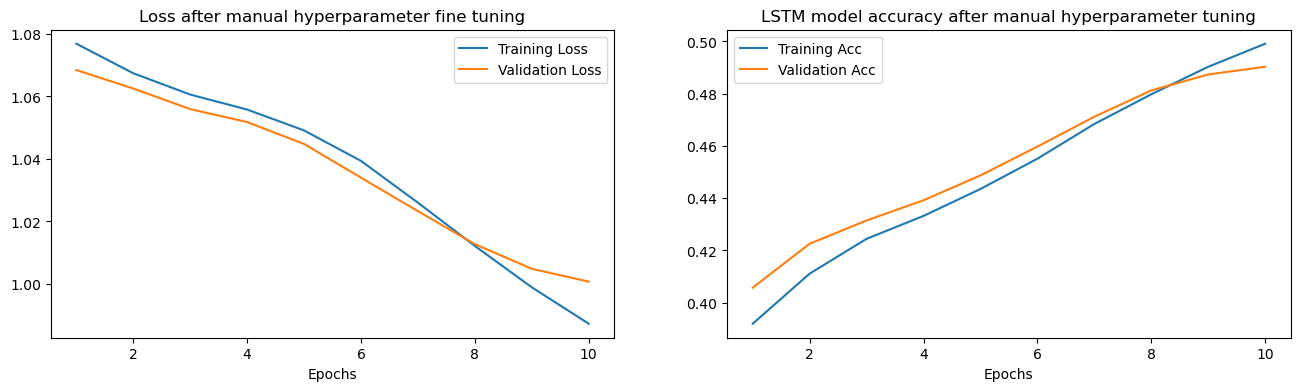

In [197]:
# Plotting the loss on the first subplot
hist_m = model_LSTM_manual_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy after manual hyperparameter tuning')
plt.show()

It seems that with more training, the accuracy can potentially get quite a bit better; thus, let's try continuing training the model with more epochs

In [355]:
# Continuing to train the model (to get to 50 epochs)
num_epochs_cont = 40
model_LSTM_manual_fit = model_LSTM_manual.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.1,
    epochs = num_epochs_cont,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.5147 - loss: 0.9690 - val_accuracy: 0.5006 - val_loss: 0.9878
Epoch 2/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - accuracy: 0.5223 - loss: 0.9581 - val_accuracy: 0.5056 - val_loss: 0.9846
Epoch 3/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.5282 - loss: 0.9491 - val_accuracy: 0.5095 - val_loss: 0.9834
Epoch 4/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.5353 - loss: 0.9398 - val_accuracy: 0.5068 - val_loss: 0.9846
Epoch 5/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.5406 - loss: 0.9325 - val_accuracy: 0.5099 - val_loss: 0.9876
Epoch 6/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.5450 - loss: 0.9243 - val_accuracy: 0.5076 - val_loss: 0.9972
Epoch 7/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.5516 - loss: 0.9169 - val_accuracy: 0.5061 - val_loss: 1.0043
Epoch 8/40
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.5556 - loss: 0

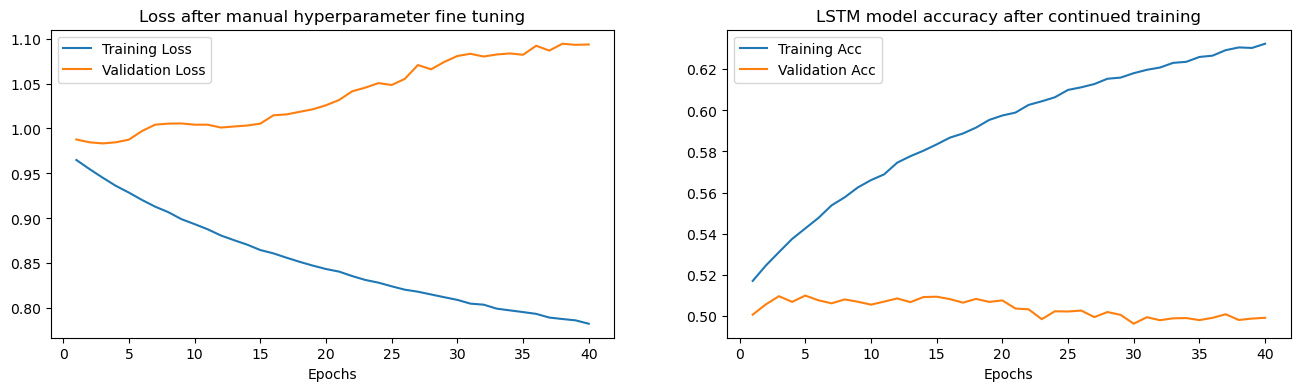

In [356]:
# Plotting the loss on the first subplot
hist_m = model_LSTM_manual_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs_cont+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs_cont+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs_cont+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs_cont+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy after continued training')
plt.show()

As we can see from above, there's no reason to train it any longer as we're seeming to overfit.

Testing against the test dataset (X_test and Y_test)

In [349]:
# Evaluating the model against X_test and Y_test
model_LSTM_manual.evaluate(X_test, Y_test)

2643/2643 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.4027 - loss: 1.1047


[1.1034297943115234, 0.40230631828308105]

It seems to do horribly with the test dataset, which is a little surprising since the validation results seem to indicate the opposite

### Building and compiling Keras tuner LSTM model
Note: we'll be creating our own Keras tuner class so we can alter batch size as we see fit

In [198]:
# Building custom hypermodel class to alter the batch size
class MyHyperModel(kt.HyperModel):
    def build(self, hp):
    
        # Resetting tf for consistent results
        tf.keras.backend.clear_session()
        np.random.seed(0)
        tf.random.set_seed(0)
    
        # Building a model using tf Sequential
        model = tf.keras.Sequential()

        # Input layer
        model.add(tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2]), name='Input'))

        # Tune the number of units in the LSTM layers
        hp_units = hp.Choice('units', values=[32, 64, 128, 256])
    
        # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
        model.add(LSTM(units=hp_units, return_sequences=True, name='LSTM_1'))
        model.add(Dropout(0.2, name='Dropout_1'))
        model.add(LSTM(units=hp_units, name='LSTM_2'))
        model.add(Dropout(0.2, name='Dropout_2'))
    
        # Output layer
        model.add(tf.keras.layers.Dense(
          units = 3,
          activation = 'softmax',
          name = 'Output'
        ))
        
        # Tune the learning rate for the optimizer
        # Choose an optimal value from 0.0001, 0.001, 0.01, or 0.05
        hp_learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2, 5e-2])
        
        # Setting optimizer and specific learning rate
        optimizer_class = getattr(tf.keras.optimizers, 'Adam')
        optimizer_true = optimizer_class(learning_rate=hp_learning_rate)
        
        # Compiling the model
        model.compile(optimizer=optimizer_true,
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                      metrics=['accuracy'])
        
        return model

    # This is where we add the batch size, and based on our results from the
    # manual tuning, we will have one of 4 possible batch sizes
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
          *args,
          batch_size=hp.Choice("batch_size", [128, 256, 512, 1024]),
          **kwargs,
        )
        

In [199]:
# Instantiating Hyperband tuner (with the objective being the validation loss)
tuner_log_c = kt.Hyperband(MyHyperModel(),
    objective="val_loss",
    max_epochs=20,
    factor=3,
    overwrite=True
)

In [200]:
# Creating a callback to stop training early after reaching a certain value for
# the validation loss (i.e., if val_loss hasn't improved in 3 epochs, it will move on)
stop_early_c = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

In [201]:
# Running the hyperparameter search
tuner_log_c.search(X_train, Y_train, epochs=20, validation_split=0.1,
  callbacks=[stop_early_c])

# Get the optimal hyperparameters
best_hps_c = tuner_log_c.get_best_hyperparameters(num_trials=1)[0]
best_hps_c.values

Trial 30 Complete [00h 37m 00s]
val_loss: 0.9873153567314148

Best val_loss So Far: 0.9781613349914551
Total elapsed time: 02h 48m 07s


{'units': 256,
 'learning_rate': 0.001,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 7,
 'tuner/bracket': 2,
 'tuner/round': 2,
 'batch_size': 128,
 'tuner/trial_id': '0012'}

In [202]:
print(f"""
The hyperparameter search is complete. The optimal number of units in the LSTM
layers is {best_hps_c.get('units')}, the optimal learning rate for the optimizer
is {best_hps_c.get('learning_rate')}, and the optimal batch size for the optimizer
is {best_hps_c.get('batch_size')} .
""")


The hyperparameter search is complete. The optimal number of units in the LSTM
layers is 256, the optimal learning rate for the optimizer
is 0.001, and the optimal batch size for the optimizer
is 128 .



In [203]:
# Training the model the same way as before, but using the tuner class above
model_hp_c = tuner_log_c.hypermodel.build(best_hps_c)
history_hp_c = model_hp_c.fit(X_train, Y_train, epochs=20,
  batch_size=best_hps_c.get('batch_size'), validation_split=0.1)

val_loss_per_epoch_c = history_hp_c.history['val_loss']
best_epoch_c = val_loss_per_epoch_c.index(min(val_loss_per_epoch_c)) + 1
print('Best epoch: %d' % (best_epoch_c,))

Epoch 1/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 149s 59ms/step - accuracy: 0.3918 - loss: 1.0771 - val_accuracy: 0.4258 - val_loss: 1.0593
Epoch 2/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 149s 60ms/step - accuracy: 0.4314 - loss: 1.0568 - val_accuracy: 0.4475 - val_loss: 1.0446
Epoch 3/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 147s 59ms/step - accuracy: 0.4588 - loss: 1.0349 - val_accuracy: 0.4798 - val_loss: 1.0122
Epoch 4/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 147s 59ms/step - accuracy: 0.4888 - loss: 0.9982 - val_accuracy: 0.4983 - val_loss: 0.9927
Epoch 5/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 152s 61ms/step - accuracy: 0.5110 - loss: 0.9695 - val_accuracy: 0.5096 - val_loss: 0.9811
Epoch 6/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 154s 61ms/step - accuracy: 0.5295 - loss: 0.9434 - val_accuracy: 0.5150 - val_loss: 0.9779
Epoch 7/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 158s 63ms/step - accuracy: 0.5458 - loss: 0.9193 - val_accuracy: 0.5153 - val_loss: 0.9819
Epoch 8/20
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 150s 60ms/step - accuracy: 

In [204]:
# Re-instantiating the hypermodel and training it with the optimal number of
# epochs from above
hypermodel_c = tuner_log_c.hypermodel.build(best_hps_c)

# Retrain the model
hypermodel_c_fit = hypermodel_c.fit(
    X_train,
    Y_train,
    epochs=best_epoch_c,
    validation_split=0.1,
    batch_size = best_hps_c.get('batch_size'))

Epoch 1/6
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 153s 61ms/step - accuracy: 0.3926 - loss: 1.0767 - val_accuracy: 0.4274 - val_loss: 1.0589
Epoch 2/6
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 156s 62ms/step - accuracy: 0.4311 - loss: 1.0572 - val_accuracy: 0.4462 - val_loss: 1.0458
Epoch 3/6
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 156s 62ms/step - accuracy: 0.4581 - loss: 1.0353 - val_accuracy: 0.4814 - val_loss: 1.0114
Epoch 4/6
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 152s 61ms/step - accuracy: 0.4898 - loss: 0.9981 - val_accuracy: 0.4963 - val_loss: 0.9921
Epoch 5/6
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 156s 62ms/step - accuracy: 0.5103 - loss: 0.9708 - val_accuracy: 0.5072 - val_loss: 0.9815
Epoch 6/6
2509/2509 ━━━━━━━━━━━━━━━━━━━━ 155s 62ms/step - accuracy: 0.5281 - loss: 0.9446 - val_accuracy: 0.5124 - val_loss: 0.9777


In [205]:
print("While this is more promising, it's still not the greatest. Our validation accuracy is barely any better, and this took a")
print("monumental amount of time to run.")

While this is more promising, it's still not the greatest. Our validation accuracy is barely any better, and this took a
monumental amount of time to run.


In [206]:
print("Checking out the final accuracy shows us that it hasn't improved much from before:")
print(" - Accuracy using Keras Tuner:")
print(" - Training accuracy:", hypermodel_c.evaluate(X_train, Y_train, verbose = 1)[1])

print("And we see that the test accuracy isn't improved by much either:")
print(" - Test data accuracy:", hypermodel_c.evaluate(X_test, Y_test, verbose = 1)[1])

Checking out the final accuracy shows us that it hasn't improved much from before:
 - Accuracy using Keras Tuner:
11148/11148 ━━━━━━━━━━━━━━━━━━━━ 109s 10ms/step - accuracy: 0.5550 - loss: 0.9087
 - Training accuracy: 0.5495269298553467
And we see that the test accuracy isn't improved by much either:
2643/2643 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.4052 - loss: 1.1098
 - Test data accuracy: 0.40351271629333496


## LSTM Classification (one stock - AAPL, sector dummy features not included)

### Getting just data for AAPL

In [207]:
# Filtering for just AAPL
train_aapl = train_data[train_data['Ticker'] == 'AAPL']
train_aapl = train_aapl.iloc[:,:-12]
test_aapl = test_data[test_data['Ticker'] == 'AAPL']
test_aapl = test_aapl.iloc[:,:-12]

### Getting X sequence data and Y labels

In [208]:
# Creating sequences for LSTM model
seq_length = 14
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_train, Y_train = create_sequences_grouped(train_aapl, seq_length, group_col, target_col, drop_cols)
X_test, Y_test = create_sequences_grouped(test_aapl, seq_length, group_col, target_col, drop_cols)

In [209]:
# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape)

Shape of X_train: (751, 14, 20)
Shape of Y_train: (751,)
Shape of X_test: (178, 14, 20)
Shape of Y_test: (178,)


### Building and compiling LSTM model

In [210]:
# Defining a function to create and compile tf model (with 256 units as defined by previous Keras Tuner model)
def build_LSTM_model_AAPL(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [213]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting best hyperparameters after manually tuning
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
learning_rate = 0.0001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 16

# Building and compiling the model
model_LSTM_AAPL = build_LSTM_model_AAPL(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      learning_rate=learning_rate,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_AAPL.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 256)        │       283,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 809,731 (3.09 MB)

 Trainable params: 809,731 (3.09 MB)

 Non-trainable params: 0 (0.00 B)

None


In [214]:
# Training the model using the training dataset
model_LSTM_AAPL_fit = model_LSTM_AAPL.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.1,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.3926 - loss: 1.0980 - val_accuracy: 0.2500 - val_loss: 1.1127
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3633 - loss: 1.1044 - val_accuracy: 0.3158 - val_loss: 1.1100
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3703 - loss: 1.0991 - val_accuracy: 0.3553 - val_loss: 1.1040
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3712 - loss: 1.0941 - val_accuracy: 0.3816 - val_loss: 1.1049
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3728 - loss: 1.0956 - val_accuracy: 0.3816 - val_loss: 1.1057
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3770 - loss: 1.0919 - val_accuracy: 0.4079 - val_loss: 1.1043
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3593 - loss: 1.1002 - val_accuracy: 0.3947 - val_loss: 1.1061
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3754 - loss: 1.0891 - val_accuracy: 0.4079 - v

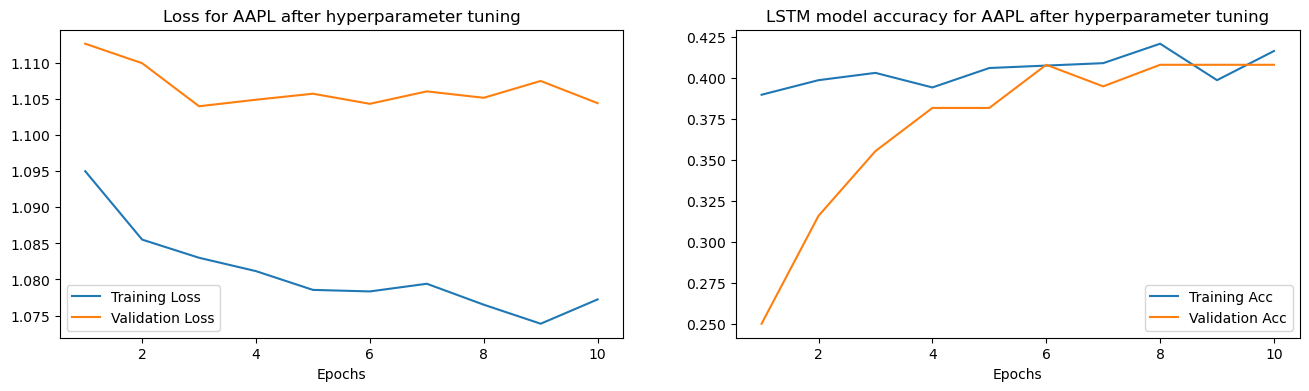

In [215]:
# Plotting the loss on the first subplot
hist_a = model_LSTM_AAPL_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_a['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_a['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for AAPL after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_a['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_a['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for AAPL after hyperparameter tuning')
plt.show()

In [216]:
# Evaluating the model against X_test and Y_test
model_LSTM_AAPL.evaluate(X_test, Y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4189 - loss: 1.0985


[1.0883287191390991, 0.42696627974510193]

With just AAPL using this updated dataset, the model seems to actually perform better than the previous dataset. The validation loss is worse than the training loss, but the validation accuracy was pretty comparable at the end. However, we see that we still can't approach a training or validation accuracy of 50%, unlike when we used all the stocks. Again, this could indicate that AAPL is simply hard to predict, or that there are indeed certain patterns and we just don't have enough data.

In either case, we can test using the entire Information Technology sector and see what we get from there.

## LSTM Classification (one sector (Information Technology), sector dummy features not included)

### Getting data for just the Information Technology sector

In [228]:
# Filtering for just the Information Technology sector
train_it = train_data[train_data['Information Technology']]
train_it = train_it.iloc[:,:-12]
test_it = test_data[test_data['Information Technology']]
test_it = test_it.iloc[:,:-12]

### Getting X sequence data and Y labels

In [229]:
# Creating sequences for LSTM model
seq_length = 14
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_train, Y_train = create_sequences_grouped(train_it, seq_length, group_col, target_col, drop_cols)
X_test, Y_test = create_sequences_grouped(test_it, seq_length, group_col, target_col, drop_cols)

In [230]:
# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape)

Shape of X_train: (39052, 14, 20)
Shape of Y_train: (39052,)
Shape of X_test: (9256, 14, 20)
Shape of Y_test: (9256,)


### Building and compiling LSTM model

In [231]:
# Defining a function to create and compile tf model (with 256 units as defined by previous Keras Tuner model)
def build_LSTM_model_it(seq_length,
                     num_features,
                     n_classes,
                     learning_rate=0.01,
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [232]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting best hyperparameters after manually tuning
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
learning_rate = 0.001
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 15
batch_size = 128

# Building and compiling the model
model_LSTM_it = build_LSTM_model_it(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      learning_rate=learning_rate,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_it.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 256)        │       283,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 809,731 (3.09 MB)

 Trainable params: 809,731 (3.09 MB)

 Non-trainable params: 0 (0.00 B)

None


In [233]:
# Training the model using the training dataset
model_LSTM_it_fit = model_LSTM_it.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.1,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms/step - accuracy: 0.3822 - loss: 1.0859 - val_accuracy: 0.3932 - val_loss: 1.0749
Epoch 2/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.4011 - loss: 1.0672 - val_accuracy: 0.4083 - val_loss: 1.0683
Epoch 3/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.4124 - loss: 1.0608 - val_accuracy: 0.4173 - val_loss: 1.0649
Epoch 4/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.4249 - loss: 1.0578 - val_accuracy: 0.4194 - val_loss: 1.0640
Epoch 5/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.4296 - loss: 1.0545 - val_accuracy: 0.4232 - val_loss: 1.0614
Epoch 6/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.4372 - loss: 1.0492 - val_accuracy: 0.4319 - val_loss: 1.0581
Epoch 7/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.4456 - loss: 1.0421 - val_accuracy: 0.4475 - val_loss: 1.0531
Epoch 8/15
275/275 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.4615 - loss: 1.0328 - 

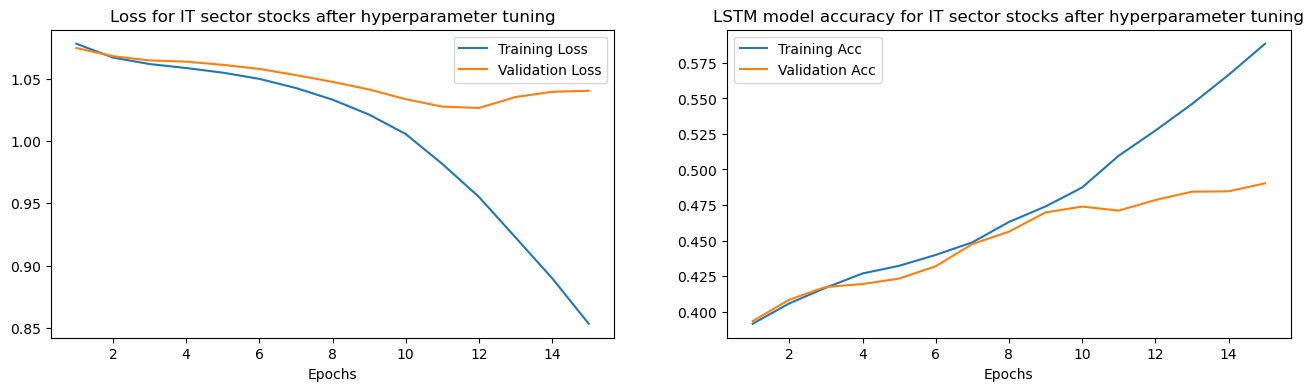

In [234]:
# Plotting the loss on the first subplot
hist_it = model_LSTM_it_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_it['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_it['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for IT sector stocks after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_it['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_it['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for IT sector stocks after hyperparameter tuning')
plt.show()

In [235]:
# Evaluating the model against X_test and Y_test
model_LSTM_it.evaluate(X_test, Y_test)

290/290 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4026 - loss: 1.1430


[1.145621418952942, 0.4103284478187561]

With the entire IT sector, the model seems to do about the same or even worse. In either case, it still doesn't seem as good as when we use the whole data. Again, this could indicate that Information Technology sector stocks are hard to predict, or it could mean that there are certain patterns in the overall dataset and we just don't have enough data.

## LSTM Classification (all stocks, longer series)

### Getting X sequence data and Y labels

In [236]:
# Creating sequences for LSTM model
seq_length = 35
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_train, Y_train = create_sequences_grouped(train_data, seq_length, group_col, target_col, drop_cols)
X_test, Y_test = create_sequences_grouped(test_data, seq_length, group_col, target_col, drop_cols)

In [237]:
# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming that we should have the correct number of sequences in X_train
unique_train_tickers = train_data['Ticker'].nunique()
unique_train_dates = train_data['Date_col'].nunique()
expected_num_sequences = unique_train_tickers * (unique_train_dates - seq_length + 1)

print('Number of unique tickers in data_train:', unique_train_tickers)
print('Number of unique dates in data_train:', unique_train_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_train_dates - seq_length + 1)
print('(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window')
print('of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)\n')
print('Total number of train sequences expected:', expected_num_sequences)
print('Total number of train sequences achieved:', X_train.shape[0])

Shape of X_train: (346750, 35, 32)
Shape of Y_train: (346750,)
Shape of X_test: (74575, 35, 32)
Shape of Y_test: (74575,) 

Number of unique tickers in data_train: 475
Number of unique dates in data_train: 764
Chosen sequence length: 35
Number of sequences assuming the above seq_length: 730
(We need to add 1 to the end to account for either the beginning or the end. For example, if we had 12 observations with a window
of 5, we would need 12 - 5 + 1 = 8 sequences, the first one being having indices from [0:5], and the last from [7:12].)

Total number of train sequences expected: 346750
Total number of train sequences achieved: 346750


### Building and compiling LSTM model

In [240]:
# Defining a function to create and compile tf model (256 LSTM units with longer series)
def build_LSTM_model_long(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [241]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train.shape[1]
num_features = X_train.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 1024

# Building and compiling the model
model_LSTM_long = build_LSTM_model_long(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_long.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 35, 256)        │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 35, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,019 (3.14 MB)

 Trainable params: 822,019 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

None


In [242]:
# Training the model using the training dataset
model_LSTM_long_fit = model_LSTM_long.fit(
    x = X_train,
    y = Y_train,
    validation_split = 0.1,
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 209s 682ms/step - accuracy: 0.3823 - loss: 1.0896 - val_accuracy: 0.4139 - val_loss: 1.0682
Epoch 2/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 221s 724ms/step - accuracy: 0.4090 - loss: 1.0676 - val_accuracy: 0.4247 - val_loss: 1.0601
Epoch 3/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 210s 690ms/step - accuracy: 0.4245 - loss: 1.0602 - val_accuracy: 0.4335 - val_loss: 1.0544
Epoch 4/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 205s 670ms/step - accuracy: 0.4374 - loss: 1.0534 - val_accuracy: 0.4472 - val_loss: 1.0472
Epoch 5/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 203s 666ms/step - accuracy: 0.4498 - loss: 1.0438 - val_accuracy: 0.4649 - val_loss: 1.0314
Epoch 6/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 194s 636ms/step - accuracy: 0.4706 - loss: 1.0227 - val_accuracy: 0.4855 - val_loss: 1.0082
Epoch 7/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 200s 656ms/step - accuracy: 0.4949 - loss: 0.9928 - val_accuracy: 0.5043 - val_loss: 0.9860
Epoch 8/10
305/305 ━━━━━━━━━━━━━━━━━━━━ 202s 664ms/step - accuracy: 0.5163 -

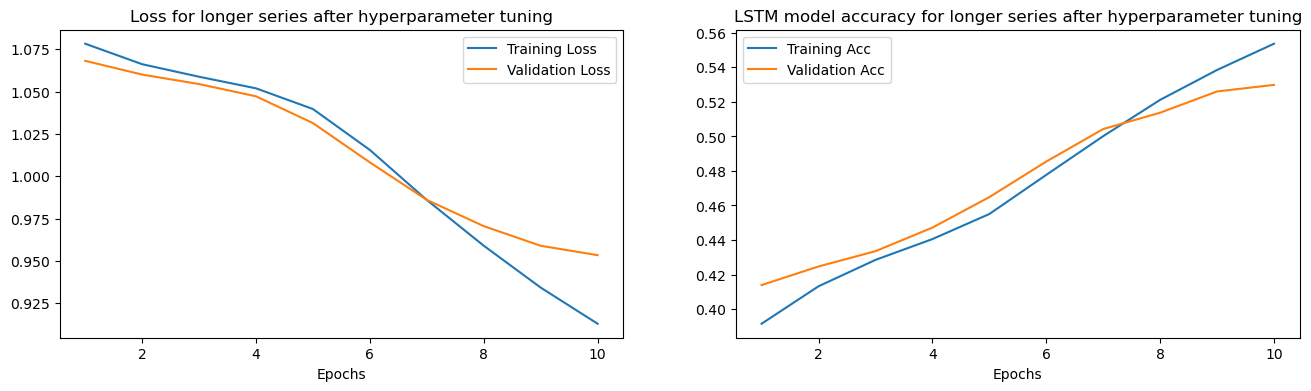

In [243]:
# Plotting the loss on the first subplot
hist_l = model_LSTM_long_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_l['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_l['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss for longer series after hyperparameter tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_l['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_l['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy for longer series after hyperparameter tuning')
plt.show()

As it takes over 3 minutes to run each epoch, and the validation accuracy seems to be plateauing now, it probably doesn't make sense to waste more compute and continue running. However, even with this run, we see that the validation accuracy almost reaches 54%, which is an improvement over the previous model with a smaller window of 14 days.

In [244]:
print("Final training accuracy:", hist_l['accuracy'][-1])
print("Final validation accuracy:", hist_l['val_accuracy'][-1])

Final training accuracy: 0.5537066459655762
Final validation accuracy: 0.5298629999160767


Testing against the test dataset (X_test and Y_test)

In [245]:
# Evaluating the model against X_test and Y_test
model_LSTM_long.evaluate(X_test, Y_test)

2331/2331 ━━━━━━━━━━━━━━━━━━━━ 93s 40ms/step - accuracy: 0.4076 - loss: 1.1066


[1.104481816291809, 0.4087160527706146]

However, we still run into the problem of the test dataset having a terrible accuracy. Even more so, the accuracy seems to be similar to previous test accuracies, which indicates that the model in the current state might just not be applicable.

## Conclusions for True Sequence LSTM Models with 80/20 Train/Test Split
The conclusions are unfortunately the same as when we used the original (Open-normalized) sequence data, where the test accuracies are much worse than the training and validation accuracies. This is somewhat surprising, as we expected the long-term changes in price and volume features to have more of an effect than they actually did. Nevertheless, this result still somewhat makes sense, as our test data is still quite far (in time) from our training data, and we're not using as much training data as we could be. In the next notebook, we will try again with the 99/1 train/test split with this corrected dataset to see how those models perform.